In [1]:
import pandas as pd
import numpy as np

import matplotlib as mpl
from matplotlib import pyplot as plt

In [2]:
data_df = pd.read_csv("https://www.statlearning.com/s/Advertising.csv", index_col=0)

In [3]:
data_df

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


Text(0, 0.5, 'sales')

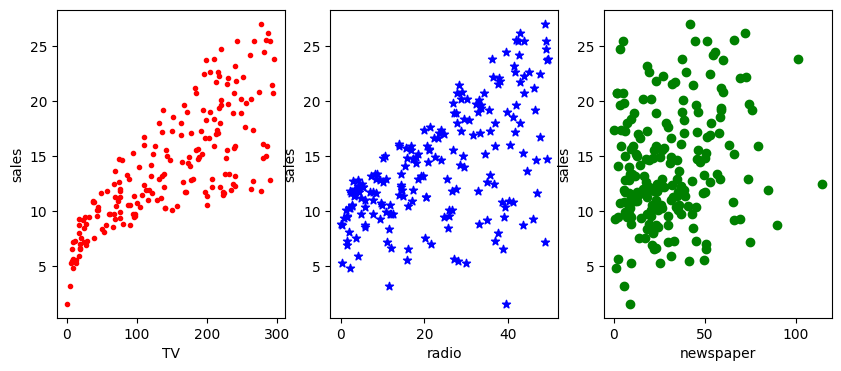

In [4]:
fig = plt.figure(figsize=(10, 4))
gs = mpl.gridspec.GridSpec(1, 3) # row * column

# plot of sales vs TV
ax = fig.add_subplot(gs[0])
ax.scatter(data_df["TV"], data_df["sales"], color = "red", marker = ".")
ax.set_xlabel("TV")
ax.set_ylabel("sales")

# plot of sales vs radio
ax = fig.add_subplot(gs[1])
ax.scatter(data_df["radio"], data_df["sales"], color = "blue", marker = "*")
ax.set_xlabel("radio")
ax.set_ylabel("sales")

# plot of sales vs newspaper
ax = fig.add_subplot(gs[2])
ax.scatter(data_df["newspaper"], data_df["sales"], color = "green", marker = "o")
ax.set_xlabel("newspaper")
ax.set_ylabel("sales")

In [5]:
X = data_df.TV.to_numpy()
Y = data_df.sales.to_numpy()

In [6]:
x_mean = X.mean()
y_mean = Y.mean()

In [7]:
beta_1 = np.sum((X - x_mean) * (Y - y_mean)) / np.sum((X - x_mean) ** 2)
beta_0 = y_mean - beta_1 * x_mean

In [8]:
print(f"y = {beta_0:.2f} + {beta_1:.2f}x")

y = 7.03 + 0.05x


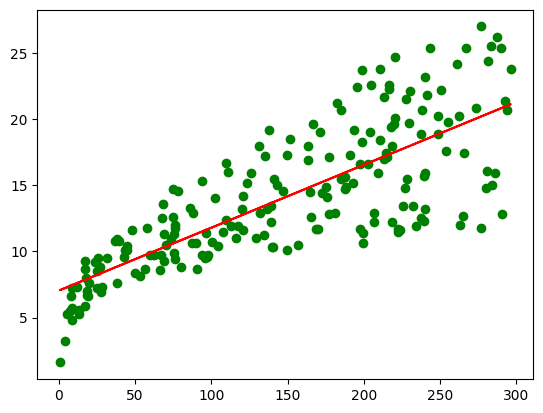

In [9]:
plt.scatter(X, Y, color = "green")
plt.plot(X, beta_0 + beta_1 * X, color = "red")
plt.show()

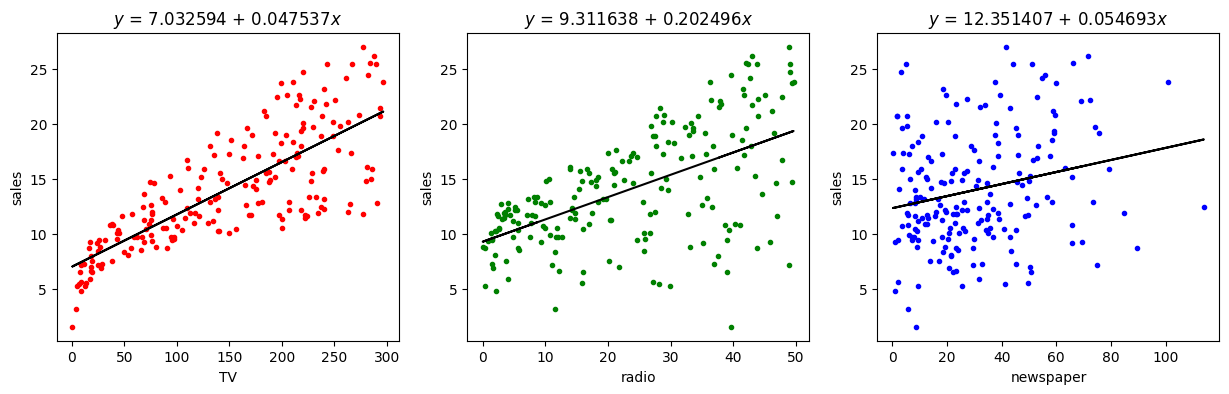

In [10]:
fig = plt.figure(figsize=(15,4))
gs = mpl.gridspec.GridSpec(1,3)

def train_plot(data_df, feature, ax, c):
  X = data_df[feature].to_numpy()
  Y = data_df['sales'].to_numpy()

  x_mean = X.mean()
  y_mean = Y.mean()

  beta_1 = np.sum((X - x_mean) * (Y - y_mean)) /np.sum(np.power((X - x_mean), 2))
  beta_0 = y_mean - (beta_1 * x_mean)

  y_hat = beta_0 + np.dot(X, beta_1)

  # plotthe regression lines
  ax.scatter(data_df[feature], data_df["sales"], color = c, marker=".")
  ax.plot(X, y_hat, color="black")
  ax.set_xlabel(feature)
  ax.set_ylabel("sales")
  ax.set_title(("$y$ = %2f + %2f$x$" %(beta_0, beta_1)))

ax0 = fig.add_subplot(gs[0])
train_plot(data_df, "TV", ax0, "red")

ax1 = fig.add_subplot(gs[1])
train_plot(data_df, "radio", ax1, "green")

ax2 = fig.add_subplot(gs[2])
train_plot(data_df, "newspaper", ax2, "blue")

In [11]:
# implementation using sklearn

from sklearn.linear_model import LinearRegression

In [12]:
linear_reg = LinearRegression()

In [13]:
X.shape

(200,)

In [14]:
Y.shape

(200,)

In [15]:
X.reshape(-1,1).shape # reshape (rows, column)

(200, 1)

In [16]:
linear_reg.fit(X.reshape(-1,1), Y.reshape(-1,1))

LinearRegression()

In [17]:
linear_reg.coef_

array([[0.04753664]])

In [18]:
linear_reg.intercept_

array([7.03259355])